# Prédiction du Décrochage Académique
## Random Forest (Données comportementalles + institutionnelles)

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive monté.")

Mounted at /content/drive
✅ Google Drive monté.


In [2]:
#imports globaux
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (train_test_split, learning_curve,
                                     validation_curve, StratifiedKFold,
                                     RandomizedSearchCV, GridSearchCV)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, roc_auc_score,
                              confusion_matrix, classification_report,
                              ConfusionMatrixDisplay, RocCurveDisplay,
                              PrecisionRecallDisplay, precision_recall_curve)
from imblearn.over_sampling import SMOTE
from scipy.stats import randint, uniform
import xgboost as xgb

print("✅ Imports effectués avec succès.")

✅ Imports effectués avec succès.


---
# PARTIE 1 — Pipeline du Random Forest sur les données comportementales


## Chargement du dataset

In [3]:
df = pd.read_excel('/content/drive/MyDrive/DROPOUT_TOOLS/dataset_564_échantillons.xlsx')

target_col = "27.Avez-vous déjà envisagé d’abandonner vos études ?"

print(f"✅ Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes.")
print(f"\nDistribution de la cible :")
print(df[target_col].value_counts())
print(f"\nAperçu :")
print(df.head(3))

✅ Dataset chargé : 564 lignes, 27 colonnes.

Distribution de la cible :
27.Avez-vous déjà envisagé d’abandonner vos études ?
Non    378
Oui    186
Name: count, dtype: int64

Aperçu :
  1.Tranche d’âge 2.Genre 3.Niveau d’étude actuel  \
0  24 ans ou plus   Femme          Licence 2 (L2)   
1  24 ans ou plus   Homme          Licence 3 (L3)   
2       21–23 ans   Homme          Master (M1/M2)   

  4.Quelle est votre moyenne générale la plus récente ?  \
0                                         Plus de 14      
1                                     Entre 12 et 14      
2                                     Entre 12 et 14      

  5.Combien de matières avez-vous échouées lors de la dernière période académique ?  \
0                                          3 ou plus                                  
1                                          3 ou plus                                  
2                                             Aucune                                  

  6.À quelle fréqu

In [4]:
# Affichage des noms exacts de toutes les colonnes du jeu de données
for i, col in enumerate(df.columns):
    print(f"{i} | {repr(col)}")

0 | '1.Tranche d’âge'
1 | '2.Genre'
2 | '3.Niveau d’étude actuel'
3 | '4.Quelle est votre moyenne générale la plus récente ?'
4 | '5.Combien de matières avez-vous échouées lors de la dernière période académique ?'
5 | '6.À quelle fréquence êtes-vous absent(e) aux cours ?'
6 | '7.Combien d’heures étudiez-vous en moyenne par semaine (hors cours) ?'
7 | '8.Votre participation en classe est généralement'
8 | '9.Rendez-vous vos devoirs et travaux dans les délais ?'
9 | '10.À quel point procrastinez-vous dans vos études ?'
10 | '11.Je me sens motivé(e) dans mes études'
11 | '12.Mon niveau de stress lié aux études est :'
12 | '13.J’ai confiance en ma capacité à réussir mes études'
13 | '14.Je ressens une fatigue mentale liée aux études'
14 | '15.Disposez-vous d’un accès régulier à Internet pour vos études ?'
15 | '16.Votre environnement de travail à domicile est :'
16 | '17.Le soutien de votre entourage (famille/proches) dans vos études est :'
17 | '18.Statut_Boursier'
18 | '19.Activite_Salar

## Encodage ordinal

In [5]:

# Normalisation des apostrophes typographiques dans les noms de colonnes
# U+2019 ' → U+0027 '  (apostrophe droite standard)
df.columns = df.columns.str.replace('\u2019', "'", regex=False)\
                        .str.replace('\u2018', "'", regex=False)

ordinal_mappings = {
    "1.Tranche d'âge": {
        '18–20 ans': 0, '21–23 ans': 1, '24 ans ou plus': 2
    },
    '4.Quelle est votre moyenne générale la plus récente ?': {
        'Moins de 10': 0, 'Entre 10 et 12': 1,
        'Entre 12 et 14': 2, 'Plus de 14': 3
    },
    '5.Combien de matières avez-vous échouées lors de la dernière période académique ?': {
        'Aucune': 0, '1–2': 1, '3 ou plus': 2
    },
    '6.À quelle fréquence êtes-vous absent(e) aux cours ?': {
        'Rarement': 0, 'Parfois': 1, 'Souvent': 2
    },
    "7.Combien d'heures étudiez-vous en moyenne par semaine (hors cours) ?": {
        'Moins de 5 heures': 0, 'Entre 5 et 10 heures': 1,
        'Plus de 10 heures': 2
    },
    '8.Votre participation en classe est généralement': {
        'Moyenne': 0, 'Élevée': 1
    },
    '9.Rendez-vous vos devoirs et travaux dans les délais ?': {
        'Jamais': 0, 'Parfois': 1, 'Toujours': 2
    },
    '10.À quel point procrastinez-vous dans vos études ?': {
        'Peu': 0, 'Moyennement': 1, 'Beaucoup': 2
    },
    '11.Je me sens motivé(e) dans mes études': {
        'Pas du tout': 0, 'Peu': 1, 'Motivé(e)': 2, 'Très motivé(e)': 3
    },
    '12.Mon niveau de stress lié aux études est :': {
        'Très faible': 0, 'Faible': 1, 'Peu': 1, 'Moyen': 2, 'Élevé': 3
    },
    "13.J'ai confiance en ma capacité à réussir mes études": {
        'Peu': 0, 'Moyennement': 1, 'Confiant(e)': 2, 'Très confiant(e)': 3
    },
    '14.Je ressens une fatigue mentale liée aux études': {
        'Très faible': 0, 'Faible': 1, 'Moyenne': 2,
        'Élevée': 3, 'Très élevée': 4
    },
    "15.Disposez-vous d'un accès régulier à Internet pour vos études ?": {
        'Non': 0, 'Oui': 1
    },
    '16.Votre environnement de travail à domicile est :': {
        'Défavorable': 0, 'Moyennement favorable': 1, 'Favorable': 2
    },
    '17.Le soutien de votre entourage (famille/proches) dans vos études est :': {
        'Faible': 0, 'Moyen': 1, 'Fort': 2
    },
    '20.Niveau_Etude_Parents': {
        'Bac ou moins': 0, 'Licence': 1, 'Master ou plus': 2
    },
    '22.Mention_Bac': {
        'Sans mention': 0, 'Assez bien': 1, 'Bien': 2, 'Très bien': 3
    },
    '23.Annees_Retard': {
        '0': 0, '1': 1, '2': 2, '3+': 3
    },
    '24.Freq_Connexion_LMS': {
        'Rare': 0, 'Hebdomadaire': 1, 'Quotidienne': 2
    },
    '25.Temps_Trajet_Minutes': {
        'Moins de 30': 0, '30-60': 1, 'Plus de 60': 2
    }
}

for col, mapping in ordinal_mappings.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)
    else:
        print(f"⚠️ Colonne non trouvée : {col}")

# Vérification NaN post-encodage
nan_cols = df.isnull().sum()
nan_cols = nan_cols[nan_cols > 0]
if len(nan_cols) > 0:
    print(f"\n⚠️ NaN détectés après encodage ordinal :")
    print(nan_cols)
    for col in nan_cols.index:
        df[col] = df[col].fillna(df[col].mode()[0])
    print("✅ NaN comblés par le mode.")
else:
    print("✅ Aucun NaN après encodage ordinal.")

✅ Aucun NaN après encodage ordinal.


## Encodage cible + One-Hot Encoding

In [10]:

# Normalisation des apostrophes typographiques
df.columns = df.columns.str.replace('\u2019', "'", regex=False)\
                        .str.replace('\u2018', "'", regex=False)

# Mise à jour de target_col après normalisation
target_col = "27.Avez-vous déjà envisagé d'abandonner vos études ?"
# Encodage de la cible : Non → 0, Oui → 1
le = LabelEncoder()
df[target_col] = le.fit_transform(df[target_col])
print(f"Classes encodées : {dict(zip(le.classes_, le.transform(le.classes_)))}")

# One-Hot Encoding sur les colonnes nominales restantes :
# 2.Genre | 3.Niveau d'étude actuel | 18.Statut_Boursier
# 19.Activite_Salariee | 21.Type_Bac | 26.Type_Logement
df = pd.get_dummies(df, drop_first=True)

print(f"\n✅ One-Hot Encoding effectué.")
print(f"   Dimensions finales : {df.shape}")

Classes encodées : {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}

✅ One-Hot Encoding effectué.
   Dimensions finales : (564, 32)


## Heatmap de corrélation (exploration)

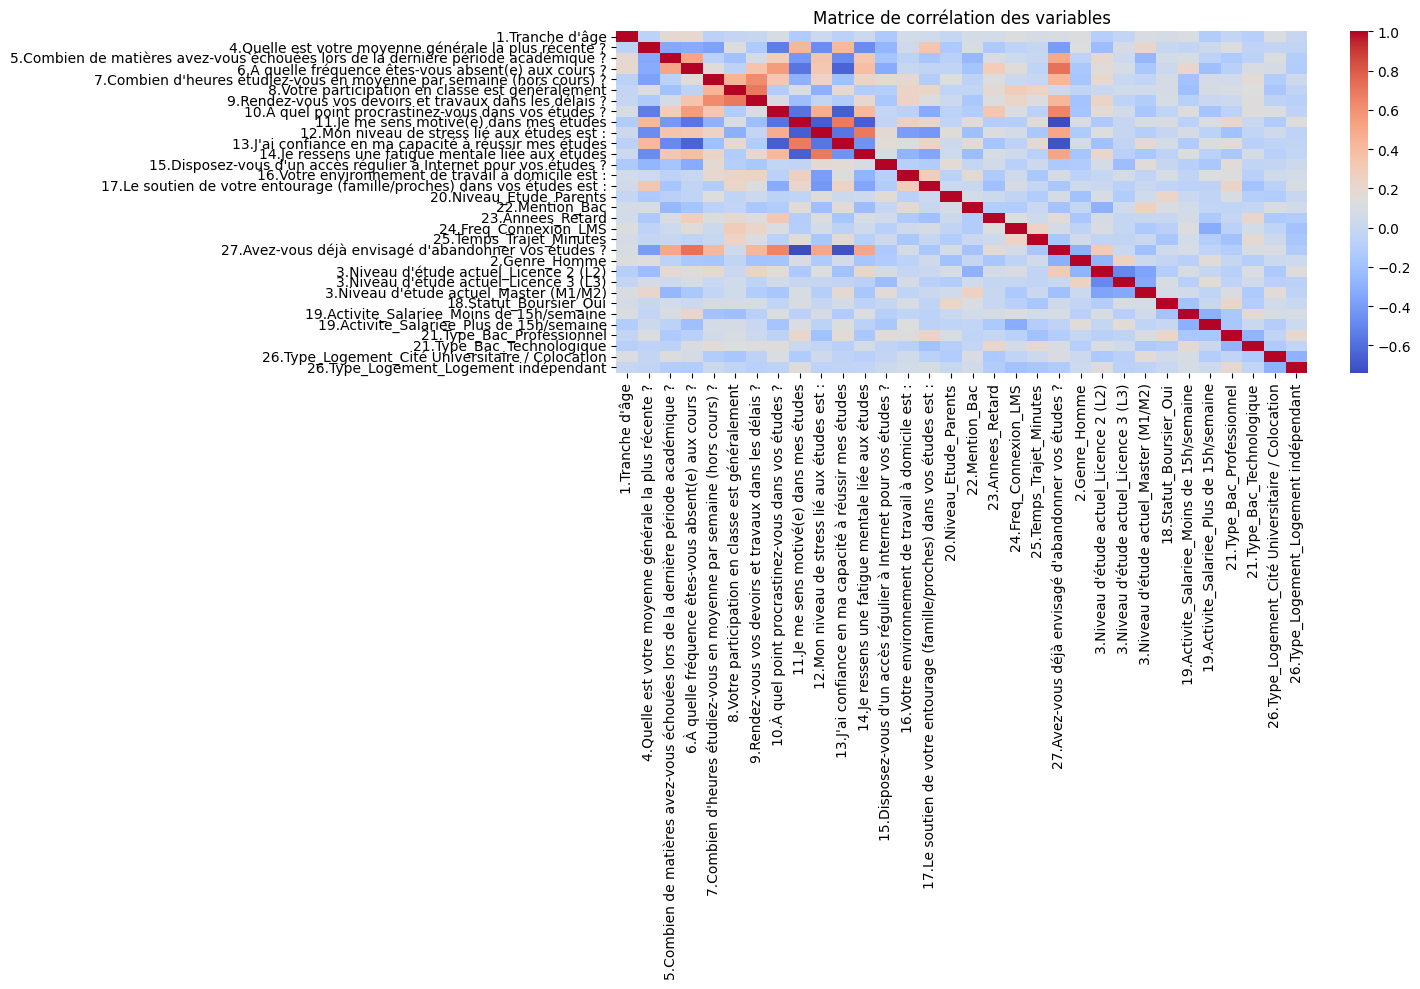

In [7]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Matrice de corrélation des variables")
plt.tight_layout()
plt.show()

## Split stratifié + Scaling + SMOTE (Train/Val/Test)


In [11]:

# Séparation X/y + Split 70/15/15 + Scaling + SMOTE

import pandas as pd
import numpy as np

path_rf = '/content/drive/MyDrive/RF_Project/'

X = df.drop(target_col, axis=1).astype(float)
y = df[target_col]

# Corrélation avec la cible
X_with_target = X.copy()
X_with_target['target'] = y.values
corr = X_with_target.corr()['target'].drop('target').abs().nlargest(10)
print("\n=== Top 10 corrélations avec la cible ===")
print(corr.to_string())

# Sauvegarde des feature names — utilisé dans pretraiter_etudiant_rf (Partie 3)
joblib.dump(X.columns.tolist(), path_rf + 'feature_names.pkl')
print(f"✅ {len(X.columns)} feature names sauvegardés → feature_names.pkl")

print(f"X : {X.shape} | y : {y.shape}")

# Split stratifié 70 / 15 / 15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"\nTrain : {X_train.shape[0]} lignes")
print(f"Val   : {X_val.shape[0]} lignes")
print(f"Test  : {X_test.shape[0]} lignes")
print(f"\nDistribution train : {y_train.value_counts().to_dict()}")
print(f"Distribution val   : {y_val.value_counts().to_dict()}")
print(f"Distribution test  : {y_test.value_counts().to_dict()}")

# Scaler fitté UNIQUEMENT sur X_train
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

joblib.dump(scaler, path_rf + 'scaler_rf.pkl')

print(f"\n✅ Scaler sauvegardé → scaler_rf.pkl")

# SMOTE appliqué UNIQUEMENT sur X_train_scaled
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

print(f"\nAprès SMOTE :")
print(f"  Train rééchantillonné : {X_train_res.shape[0]} lignes")
print(f"  Distribution          : {pd.Series(y_train_res).value_counts().to_dict()}")

# Références pour les cellules suivantes
X_test_rf = X_test_scaled
y_test_rf  = y_test
X_val_rf   = X_val_scaled
y_val_rf   = y_val


=== Top 10 corrélations avec la cible ===
11.Je me sens motivé(e) dans mes études                                              0.739537
6.À quelle fréquence êtes-vous absent(e) aux cours ?                                 0.720317
13.J'ai confiance en ma capacité à réussir mes études                                0.706302
10.À quel point procrastinez-vous dans vos études ?                                  0.652467
14.Je ressens une fatigue mentale liée aux études                                    0.514216
12.Mon niveau de stress lié aux études est :                                         0.505532
5.Combien de matières avez-vous échouées lors de la dernière période académique ?    0.503881
7.Combien d'heures étudiez-vous en moyenne par semaine (hors cours) ?                0.428219
9.Rendez-vous vos devoirs et travaux dans les délais ?                               0.422807
4.Quelle est votre moyenne générale la plus récente ?                                0.403856
✅ 31 feature name

## Sauvegarde des features names et scaler

In [12]:
path_rf = '/content/drive/MyDrive/RF_Project/'
os.makedirs(path_rf, exist_ok=True)

joblib.dump(X.columns.tolist(), path_rf + 'feature_names.pkl')
joblib.dump(scaler,             path_rf + 'scaler_rf.pkl')

print(f"✅ {len(X.columns)} feature names sauvegardées.")
print(f"✅ Scaler sauvegardé.")

✅ 31 feature names sauvegardées.
✅ Scaler sauvegardé.


## Entraînement Random Forest (données comportementales)

In [13]:

# Entraînement RF comportemental
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint

param_distributions_rf_comport = {
    'n_estimators'     : randint(100, 500),
    'max_depth'        : [3, 5, 7, 10],
    'min_samples_split': randint(5, 20),
    'min_samples_leaf' : randint(3, 10),
    'max_features'     : ['sqrt', 'log2', 0.3],
    'max_samples'      : [0.7, 0.8, 0.9]
}

rf_comport_tuning = RandomForestClassifier(
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

cv_rf_comport = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search_rf_comport = RandomizedSearchCV(
    estimator=rf_comport_tuning,
    param_distributions=param_distributions_rf_comport,
    n_iter=80,
    scoring='f1',
    cv=cv_rf_comport,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
random_search_rf_comport.fit(X_train_res, y_train_res)

rf_model = random_search_rf_comport.best_estimator_

print(f'\n✅ Meilleurs hyperparamètres : {random_search_rf_comport.best_params_}')
print(f'✅ Meilleur F1 (CV)           : {random_search_rf_comport.best_score_:.4f}')
print(f'✅ OOB Score                  : {rf_model.oob_score_:.4f}')

# Diagnostic overfitting : comparer Train vs Val
f1_train = f1_score(y_train_res, rf_model.predict(X_train_res))
f1_val   = f1_score(y_val, rf_model.predict(X_val_scaled))
gap      = f1_train - f1_val

print(f'\n--- Diagnostic overfitting ---')
print(f'   F1 Train : {f1_train:.4f}')
print(f'   F1 Val   : {f1_val:.4f}')
print(f'   Gap      : {gap:.4f}  {"⚠️ Surapprentissage" if gap > 0.10 else "✅ Acceptable"}')

Fitting 5 folds for each of 80 candidates, totalling 400 fits

✅ Meilleurs hyperparamètres : {'max_depth': 7, 'max_features': 0.3, 'max_samples': 0.8, 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 149}
✅ Meilleur F1 (CV)           : 0.9889
✅ OOB Score                  : 0.9905

--- Diagnostic overfitting ---
   F1 Train : 0.9981
   F1 Val   : 0.9655
   Gap      : 0.0326  ✅ Acceptable


## Évaluation globale

In [14]:
y_pred       = rf_model.predict(X_test_rf)
y_pred_proba = rf_model.predict_proba(X_test_rf)[:, 1]

print("=== Performance du Modèle Random Forest (sur Test) ===")
print(f"Accuracy  : {accuracy_score(y_test_rf, y_pred):.2%}")
print(f"F1        : {f1_score(y_test_rf, y_pred):.2f}")
print(f"Précision : {precision_score(y_test_rf, y_pred):.2f}")
print(f"Rappel    : {recall_score(y_test_rf, y_pred):.2f}")
print(f"AUC-ROC   : {roc_auc_score(y_test_rf, y_pred_proba):.2f}")
print("\nRapport détaillé :")
print(classification_report(y_test_rf, y_pred, target_names=['Non-Abandon', 'Abandon']))

=== Performance du Modèle Random Forest (sur Test) ===
Accuracy  : 100.00%
F1        : 1.00
Précision : 1.00
Rappel    : 1.00
AUC-ROC   : 1.00

Rapport détaillé :
              precision    recall  f1-score   support

 Non-Abandon       1.00      1.00      1.00        57
     Abandon       1.00      1.00      1.00        28

    accuracy                           1.00        85
   macro avg       1.00      1.00      1.00        85
weighted avg       1.00      1.00      1.00        85



## Cross-Validation sur 10 folds

In [15]:
# ══════════════════════════════════════════════════════
# Cross-Validation sur 10 folds — Évaluation RF comportemental
# SMOTE appliqué à l'intérieur de chaque fold via Pipeline
# pour éviter tout data leakage
# ══════════════════════════════════════════════════════
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline

# Pipeline : SMOTE → RF (avec les meilleurs hyperparamètres trouvés)
pipeline_cv = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(
        **random_search_rf_comport.best_params_,
        oob_score=False,
        random_state=42,
        n_jobs=-1
    ))
])

cv_stratified = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Métriques évaluées sur X_scaled
# On utilise X_train_scaled + X_test_scaled réunis
import numpy as np
X_scaled_complet = np.vstack([X_train_scaled, X_val_scaled, X_test_scaled])
y_complet        = pd.concat([y_train, y_val, y_test]).reset_index(drop=True)

cv_results = cross_validate(
    pipeline_cv,
    X_scaled_complet, y_complet,
    cv=cv_stratified,
    scoring={
        'accuracy' : 'accuracy',
        'f1'       : 'f1',
        'precision': 'precision',
        'recall'   : 'recall',
        'roc_auc'  : 'roc_auc'
    },
    return_train_score=True,
    n_jobs=-1
)

# Affichage
print("=== Cross-Validation 10 folds — RF comportemental ===\n")
metrics = ['accuracy', 'f1', 'precision', 'recall', 'roc_auc']
for m in metrics:
    val_mean  = cv_results[f'test_{m}'].mean()
    val_std   = cv_results[f'test_{m}'].std()
    train_mean = cv_results[f'train_{m}'].mean()
    print(f"  {m:<12} — Val: {val_mean:.4f} ± {val_std:.4f}  |  Train: {train_mean:.4f}")

# Diagnostic overfitting global
gap_f1 = cv_results['train_f1'].mean() - cv_results['test_f1'].mean()
print(f"\n  Gap F1 Train/Val : {gap_f1:.4f}  "
      f"{'⚠️ Surapprentissage' if gap_f1 > 0.10 else '✅ Acceptable'}")

print(f"\n  Détail F1 par fold : {[round(s, 4) for s in cv_results['test_f1']]}")

=== Cross-Validation 10 folds — RF comportemental ===

  accuracy     — Val: 0.9929 ± 0.0118  |  Train: 0.9986
  f1           — Val: 0.9895 ± 0.0175  |  Train: 0.9979
  precision    — Val: 0.9797 ± 0.0334  |  Train: 0.9959
  recall       — Val: 1.0000 ± 0.0000  |  Train: 1.0000
  roc_auc      — Val: 1.0000 ± 0.0000  |  Train: 1.0000

  Gap F1 Train/Val : 0.0085  ✅ Acceptable

  Détail F1 par fold : [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(0.9474), np.float64(0.973), np.float64(1.0), np.float64(0.9744), np.float64(1.0)]


## Calcul du seuil optimal

✅ Seuil optimal RF comportemental (sur Val) : 0.7843

=== Évaluation RF comportemental avec seuil optimal (sur Test) ===
  Accuracy  : 100.00%
  F1        : 1.0000
  Précision : 1.0000
  Rappel    : 1.0000
              precision    recall  f1-score   support

 Non-Abandon       1.00      1.00      1.00        57
     Abandon       1.00      1.00      1.00        28

    accuracy                           1.00        85
   macro avg       1.00      1.00      1.00        85
weighted avg       1.00      1.00      1.00        85

✅ Seuil sauvegardé → seuil_optimal_rf_comport.pkl


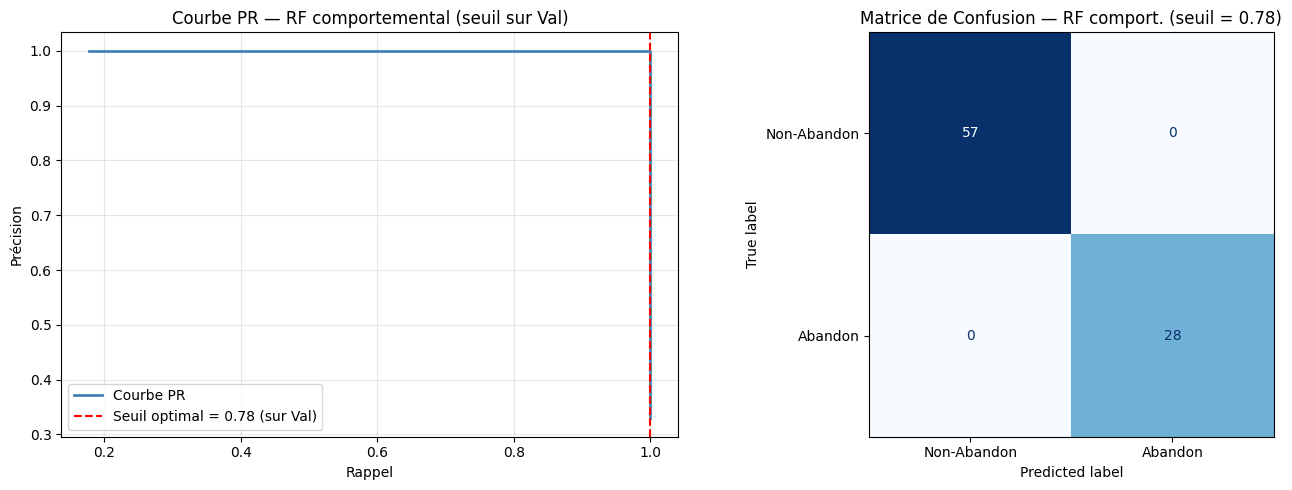

In [18]:

# Seuil optimal RF comportemental
# Seuil cherché sur l'ensemble de validation uniquement
y_proba_val_rf             = rf_model.predict_proba(X_val_scaled)[:, 1]
prec_rf, rec_rf, thresh_rf = precision_recall_curve(y_val_rf, y_proba_val_rf)
f1_rf_val                  = 2 * (prec_rf * rec_rf) / (prec_rf + rec_rf + 1e-8)
seuil_optimal_rf           = thresh_rf[np.argmax(f1_rf_val[:-1])]

print(f'✅ Seuil optimal RF comportemental (sur Val) : {seuil_optimal_rf:.4f}')

# Application sur Test
y_proba_test_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
y_pred_rf_adj   = (y_proba_test_rf >= seuil_optimal_rf).astype(int)

print('\n=== Évaluation RF comportemental avec seuil optimal (sur Test) ===')
print(f'  Accuracy  : {accuracy_score(y_test_rf, y_pred_rf_adj):.2%}')
print(f'  F1        : {f1_score(y_test_rf, y_pred_rf_adj):.4f}')
print(f'  Précision : {precision_score(y_test_rf, y_pred_rf_adj):.4f}')
print(f'  Rappel    : {recall_score(y_test_rf, y_pred_rf_adj):.4f}')
print(classification_report(
    y_test_rf, y_pred_rf_adj,
    target_names=['Non-Abandon', 'Abandon']
))

# Sauvegarde du seuil
joblib.dump(seuil_optimal_rf, path_rf + 'seuil_optimal_rf_comport.pkl')
print(f'✅ Seuil sauvegardé → seuil_optimal_rf_comport.pkl')

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rec_rf[:-1], prec_rf[:-1], color='steelblue',
             linewidth=2, label='Courbe PR')
axes[0].axvline(
    rec_rf[np.argmax(f1_rf_val[:-1])], color='red', linestyle='--',
    label=f'Seuil optimal = {seuil_optimal_rf:.2f} (sur Val)'
)
axes[0].set_xlabel('Rappel'); axes[0].set_ylabel('Précision')
axes[0].set_title('Courbe PR — RF comportemental (seuil sur Val)')
axes[0].legend(); axes[0].grid(alpha=0.3)

ConfusionMatrixDisplay(
    confusion_matrix(y_test_rf, y_pred_rf_adj),
    display_labels=['Non-Abandon', 'Abandon']
).plot(cmap=plt.cm.Blues, ax=axes[1], colorbar=False)
axes[1].set_title(
    f'Matrice de Confusion — RF comport. (seuil = {seuil_optimal_rf:.2f})'
)
plt.tight_layout(); plt.show()

In [19]:
# Vérification de cohérence
print(f"rf_model type        : {type(rf_model)}")
print(f"rf_model max_depth   : {rf_model.max_depth}")
print(f"rf_model n_estimators: {rf_model.n_estimators}")
print(f"rf_model min_samples_leaf: {rf_model.min_samples_leaf}")
print(f"\nX_test_rf shape : {X_test_rf.shape}")
print(f"y_test_rf shape : {y_test_rf.shape}")
print(f"y_test_rf distribution : {y_test_rf.value_counts().to_dict()}")

rf_model type        : <class 'sklearn.ensemble._forest.RandomForestClassifier'>
rf_model max_depth   : 7
rf_model n_estimators: 149
rf_model min_samples_leaf: 3

X_test_rf shape : (85, 31)
y_test_rf shape : (85,)
y_test_rf distribution : {0: 57, 1: 28}


## Matrice de confusion (sur Test)

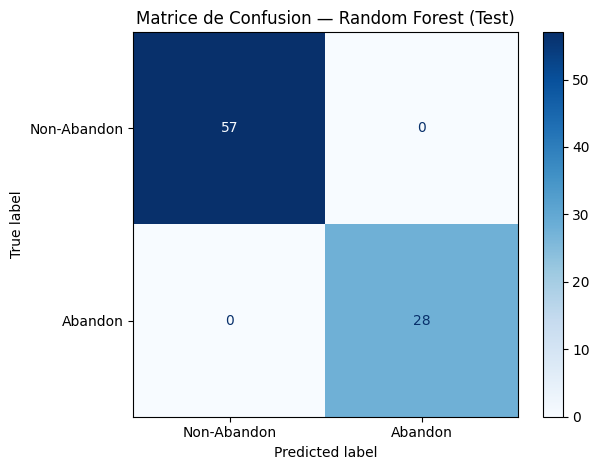

In [20]:
cm   = confusion_matrix(y_test_rf, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Non-Abandon', 'Abandon'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matrice de Confusion — Random Forest (Test)")
plt.tight_layout()
plt.show()

## Courbe ROC (sur Test)

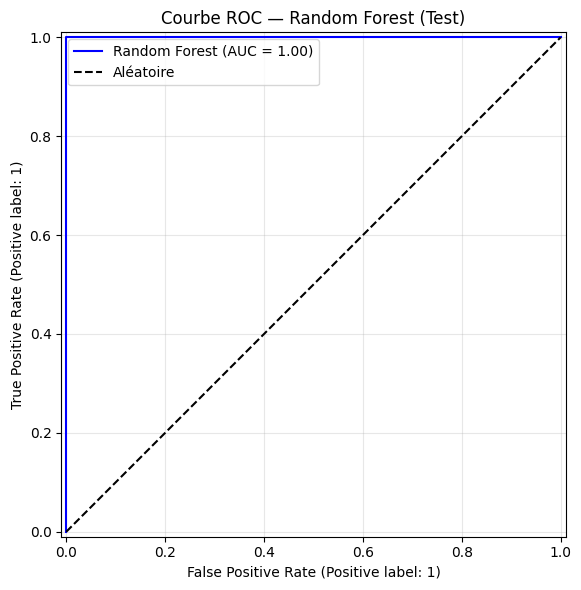

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    y_test_rf, y_pred_proba, name='Random Forest', ax=ax, color='blue'
)
ax.plot([0, 1], [0, 1], 'k--', label='Aléatoire')
ax.set_title('Courbe ROC — Random Forest (Test)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Courbe de  Précision-Rappel (sur Test)

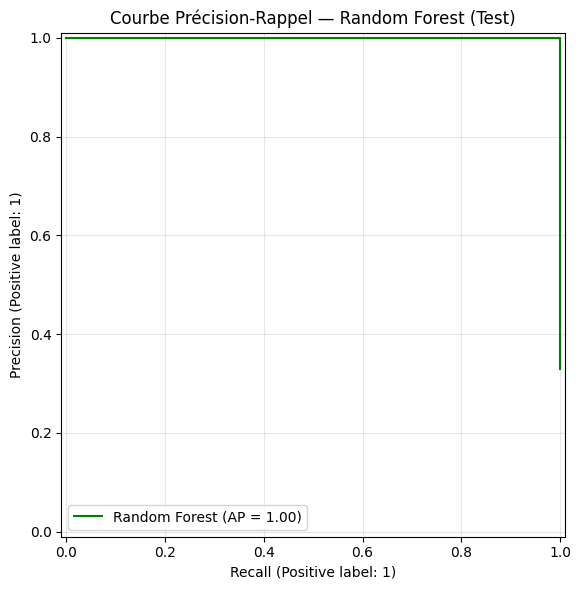

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(
    y_test_rf, y_pred_proba, name='Random Forest', ax=ax, color='green'
)
ax.set_title('Courbe Précision-Rappel — Random Forest (Test)')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Seuil de décision optimal (sur Validation)


✅ Seuil optimal RF (calculé sur Validation) : 0.7843

=== Évaluation avec seuil optimal (sur Test) ===
Accuracy  : 100.00%
F1        : 1.00
Précision : 1.00
Rappel    : 1.00
AUC-ROC   : 1.00
              precision    recall  f1-score   support

 Non-Abandon       1.00      1.00      1.00        57
     Abandon       1.00      1.00      1.00        28

    accuracy                           1.00        85
   macro avg       1.00      1.00      1.00        85
weighted avg       1.00      1.00      1.00        85



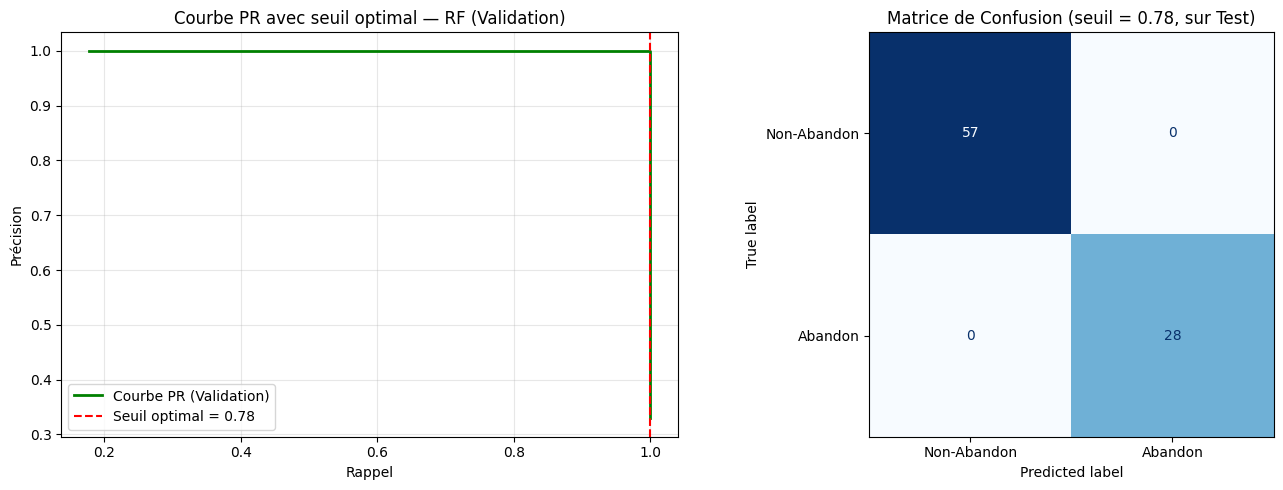

In [23]:
precisions_val, recalls_val, thresholds_val = precision_recall_curve(y_val_rf, rf_model.predict_proba(X_val_rf)[:, 1])
f1_scores_val     = 2 * (precisions_val * recalls_val) / (precisions_val + recalls_val + 1e-8)
seuil_optimal_rf = thresholds_val[np.argmax(f1_scores_val)]

print(f"✅ Seuil optimal RF (calculé sur Validation) : {seuil_optimal_rf:.4f}")

# Application du seuil optimal sur l'ensemble de TEST
y_pred_adj = (y_pred_proba >= seuil_optimal_rf).astype(int)

print("\n=== Évaluation avec seuil optimal (sur Test) ===")
print(f"Accuracy  : {accuracy_score(y_test_rf, y_pred_adj):.2%}")
print(f"F1        : {f1_score(y_test_rf, y_pred_adj):.2f}")
print(f"Précision : {precision_score(y_test_rf, y_pred_adj):.2f}")
print(f"Rappel    : {recall_score(y_test_rf, y_pred_adj):.2f}")
print(f"AUC-ROC   : {roc_auc_score(y_test_rf, y_pred_proba):.2f}")
print(classification_report(y_test_rf, y_pred_adj,
                             target_names=['Non-Abandon', 'Abandon']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(recalls_val[:-1], precisions_val[:-1], color='green', linewidth=2, label='Courbe PR (Validation)')
axes[0].axvline(recalls_val[np.argmax(f1_scores_val)], color='red', linestyle='--',
                label=f'Seuil optimal = {seuil_optimal_rf:.2f}')
axes[0].set_xlabel('Rappel'); axes[0].set_ylabel('Précision')
axes[0].set_title('Courbe PR avec seuil optimal — RF (Validation)')
axes[0].legend(); axes[0].grid(alpha=0.3)

ConfusionMatrixDisplay(
    confusion_matrix(y_test_rf, y_pred_adj),
    display_labels=['Non-Abandon', 'Abandon']
).plot(cmap=plt.cm.Blues, ax=axes[1], colorbar=False)
axes[1].set_title(f'Matrice de Confusion (seuil = {seuil_optimal_rf:.2f}, sur Test)')
plt.tight_layout(); plt.show()

## Importance des variables (sur X_train_res)

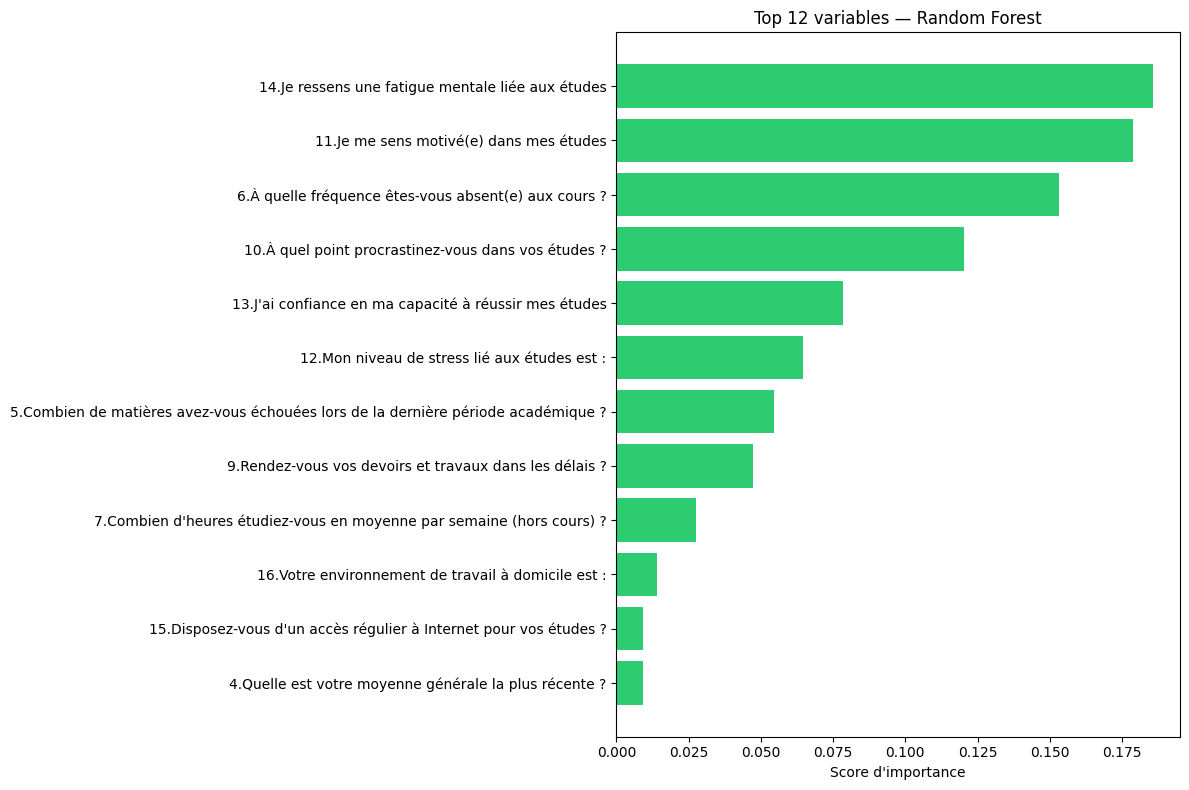


Top 12 variables :
  14.Je ressens une fatigue mentale liée aux études  : 0.1858
  11.Je me sens motivé(e) dans mes études            : 0.1787
  6.À quelle fréquence êtes-vous absent(e) aux cours ? : 0.1532
  10.À quel point procrastinez-vous dans vos études ? : 0.1203
  13.J'ai confiance en ma capacité à réussir mes études : 0.0784
  12.Mon niveau de stress lié aux études est :       : 0.0645
  5.Combien de matières avez-vous échouées lors de la dernière période académique ? : 0.0545
  9.Rendez-vous vos devoirs et travaux dans les délais ? : 0.0473
  7.Combien d'heures étudiez-vous en moyenne par semaine (hors cours) ? : 0.0274
  16.Votre environnement de travail à domicile est : : 0.0141
  15.Disposez-vous d'un accès régulier à Internet pour vos études ? : 0.0094
  4.Quelle est votre moyenne générale la plus récente ? : 0.0092


In [24]:
importances = rf_model.feature_importances_
indices     = np.argsort(importances)[::-1]
features    = X.columns

plt.figure(figsize=(12, 8))
plt.title("Top 12 variables — Random Forest")
plt.barh(range(12), importances[indices[:12]], align="center", color='#2ecc71')
plt.yticks(range(12), [features[i] for i in indices[:12]])
plt.xlabel("Score d'importance")
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

print("\nTop 12 variables :")
for i in range(12):
    print(f"  {features[indices[i]]:50s} : {importances[indices[i]]:.4f}")

## Courbe d'apprentissage


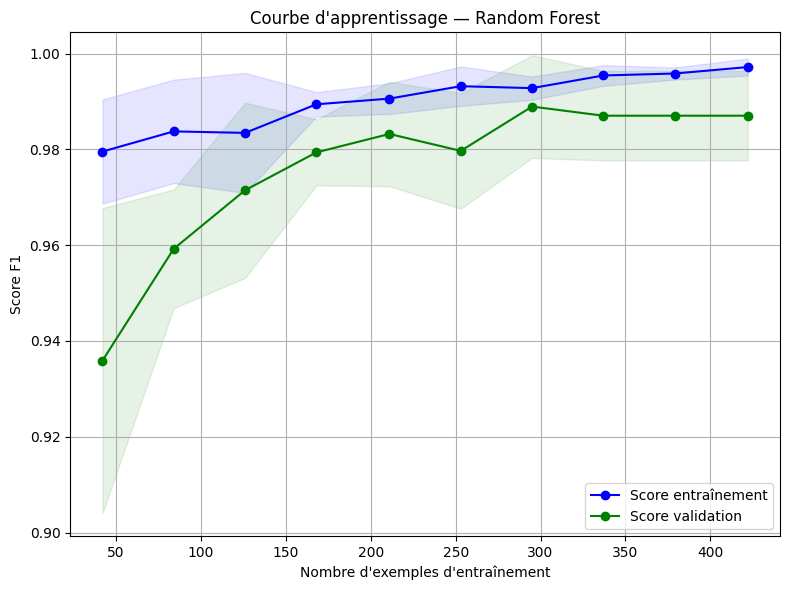

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_sizes, train_scores, valid_scores = learning_curve(
    estimator=rf_model, X=X_train_res, y=y_train_res,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=cv, scoring='f1', n_jobs=-1, shuffle=True, random_state=42
)

train_mean = np.mean(train_scores, axis=1); train_std = np.std(train_scores, axis=1)
valid_mean = np.mean(valid_scores, axis=1); valid_std = np.std(valid_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue',  label='Score entraînement')
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, valid_mean, 'o-', color='green', label='Score validation')
plt.fill_between(train_sizes, valid_mean-valid_std, valid_mean+valid_std, alpha=0.1, color='green')
plt.title("Courbe d'apprentissage — Random Forest")
plt.xlabel("Nombre d'exemples d'entraînement")
plt.ylabel("Score F1"); plt.legend(); plt.grid(); plt.tight_layout(); plt.show()

## Courbe de validation(n_estimators)

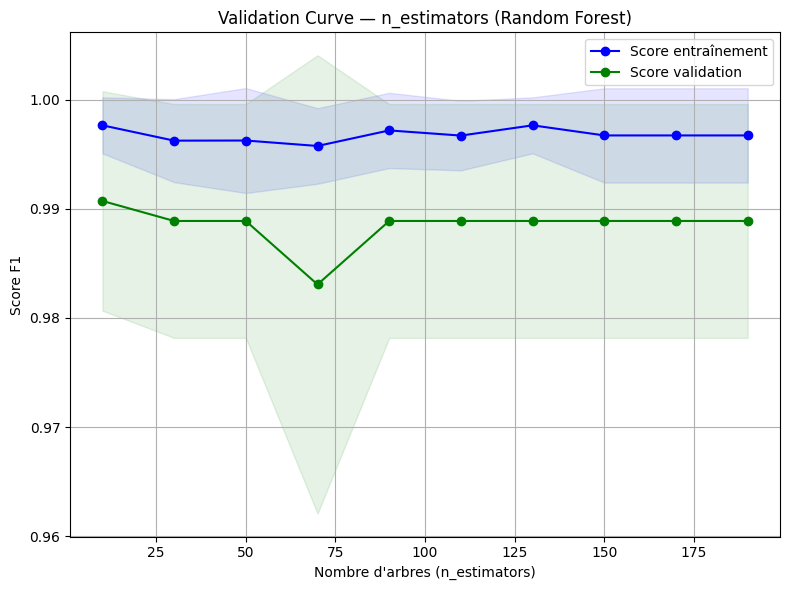

In [26]:
param_range = np.arange(10, 201, 20)

train_scores_vc, valid_scores_vc = validation_curve(
    estimator=rf_model, X=X_train_res, y=y_train_res,
    param_name="n_estimators", param_range=param_range,
    cv=StratifiedKFold(n_splits=5), scoring="f1", n_jobs=-1
)

train_mean = np.mean(train_scores_vc, axis=1); train_std = np.std(train_scores_vc, axis=1)
valid_mean = np.mean(valid_scores_vc, axis=1); valid_std = np.std(valid_scores_vc, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(param_range, train_mean, 'o-', color='blue',  label='Score entraînement')
plt.fill_between(param_range, train_mean-train_std, train_mean+train_std, alpha=0.1, color='blue')
plt.plot(param_range, valid_mean, 'o-', color='green', label='Score validation')
plt.fill_between(param_range, valid_mean-valid_std, valid_mean+valid_std, alpha=0.1, color='green')
plt.title("Validation Curve — n_estimators (Random Forest)")
plt.xlabel("Nombre d'arbres (n_estimators)")
plt.ylabel("Score F1"); plt.legend(); plt.grid(); plt.tight_layout(); plt.show()

## Distribution des probabilités prédites

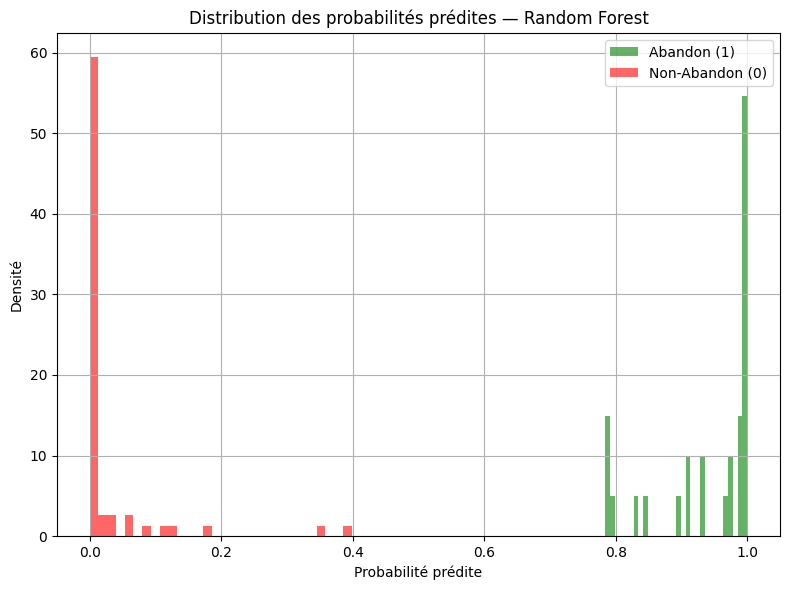

In [27]:
probs     = rf_model.predict_proba(X_test_rf)[:, 1]
probs_pos = probs[y_test_rf == 1]
probs_neg = probs[y_test_rf == 0]

plt.figure(figsize=(8, 6))
plt.hist(probs_pos, bins=30, alpha=0.6, label='Abandon (1)',     color='g', density=True)
plt.hist(probs_neg, bins=30, alpha=0.6, label='Non-Abandon (0)', color='r', density=True)
plt.title('Distribution des probabilités prédites — Random Forest')
plt.xlabel('Probabilité prédite'); plt.ylabel('Densité')
plt.legend(); plt.grid(); plt.tight_layout(); plt.show()

## Courbes Gain / Lift (sur les données de Test)

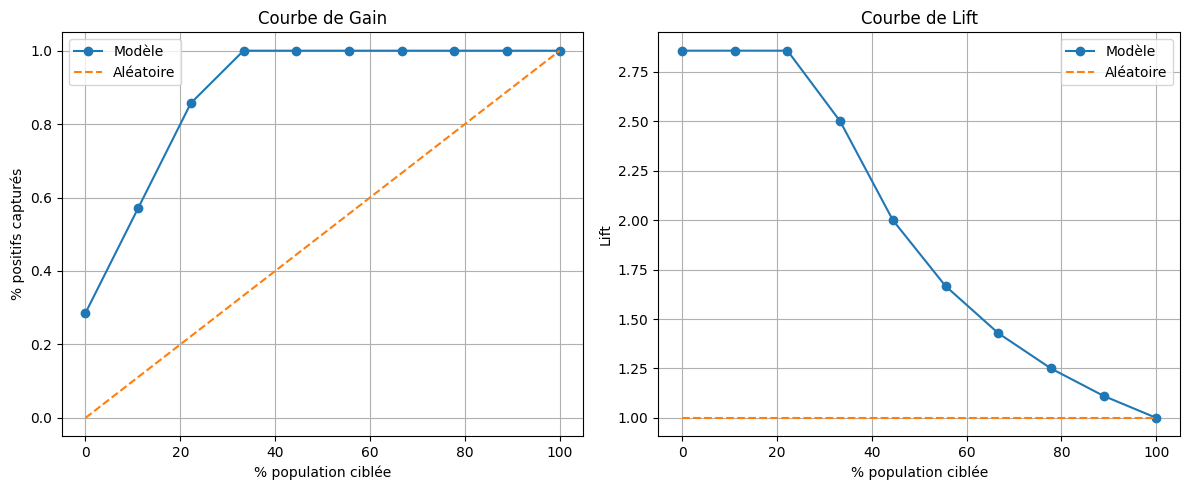

In [28]:
def plot_gain_lift(y_true, y_scores, n_bins=10):
    sorted_indices  = np.argsort(y_scores)[::-1]
    y_true_sorted   = y_true[sorted_indices]
    total_positives = np.sum(y_true)
    bin_size        = len(y_true) // n_bins
    gains, lifts    = [], []
    for i in range(1, n_bins + 1):
        gain = np.sum(y_true_sorted[:i*bin_size]) / total_positives
        gains.append(gain)
        lifts.append(gain / (i / n_bins))
    x = np.linspace(0, 100, n_bins)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(x, gains, marker='o', label='Modèle')
    plt.plot([0,100],[0,1], linestyle='--', label='Aléatoire')
    plt.title('Courbe de Gain'); plt.xlabel('% population ciblée')
    plt.ylabel('% positifs capturés'); plt.grid(True); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(x, lifts, marker='o', label='Modèle')
    plt.plot([0,100],[1,1], linestyle='--', label='Aléatoire')
    plt.title('Courbe de Lift'); plt.xlabel('% population ciblée')
    plt.ylabel('Lift'); plt.grid(True); plt.legend()
    plt.tight_layout(); plt.show()

plot_gain_lift(y_test_rf.values, rf_model.predict_proba(X_test_rf)[:, 1])

## Sauvegarde du modèle RF comportemental

In [29]:
joblib.dump(rf_model, path_rf + 'Dropout_model')
print(f"✅ Modèle RF sauvegardé : {path_rf}Dropout_model")

✅ Modèle RF sauvegardé : /content/drive/MyDrive/RF_Project/Dropout_model


---
# PARTIE 2 — Random Forest (données institutionnelles)




## Chargement du dataset institutionnel

In [ ]:
#Chargement du dataset et aperçu des colonnes
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     RandomizedSearchCV)
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, roc_auc_score,
                              confusion_matrix, classification_report,
                              ConfusionMatrixDisplay, RocCurveDisplay,
                              PrecisionRecallDisplay, precision_recall_curve)
from imblearn.over_sampling import SMOTE
from scipy.stats import randint

path_tools = '/content/drive/MyDrive/DROPOUT_TOOLS/'
os.makedirs(path_tools, exist_ok=True)

df_dataset = pd.read_csv(path_tools + 'dataset.csv', sep=',')

print('Aperçu :'); print(df_dataset.head())
print('\nInfo :'); df_dataset.info()
print('\nDistribution Target :'); print(df_dataset['Target'].value_counts())

Aperçu :
   Marital status  Application mode  Application order  Course  \
0               1                 8                  5       2   
1               1                 6                  1      11   
2               1                 1                  5       5   
3               1                 8                  2      15   
4               2                12                  1       3   

   Daytime/evening attendance  Previous qualification  Nacionality  \
0                           1                       1            1   
1                           1                       1            1   
2                           1                       1            1   
3                           1                       1            1   
4                           0                       1            1   

   Mother's qualification  Father's qualification  Mother's occupation  ...  \
0                      13                      10                    6  ...   
1              

## Binarisation de la cible






In [ ]:

# Création de la cible binaire
# Dropout → 1  |  Graduate / Enrolled → 0

df_dataset['Binary_Target'] = df_dataset['Target'].apply(
    lambda x: 1 if x == 'Dropout' else 0
)

total    = len(df_dataset)
n_drop   = df_dataset['Binary_Target'].sum()
n_nodrop = total - n_drop

print('Distribution Binary_Target :')
print(df_dataset['Binary_Target'].value_counts())
print(f'\n  Ratio déséquilibre : {n_nodrop/n_drop:.2f}:1  (Non-Dropout / Dropout)')
print(f'  → Classe minoritaire (Dropout) : {n_drop/total:.1%}')

Distribution Binary_Target :
Binary_Target
0    3003
1    1421
Name: count, dtype: int64

  Ratio déséquilibre : 2.11:1  (Non-Dropout / Dropout)
  → Classe minoritaire (Dropout) : 32.1%


## Analyse exploratoire des données : distribution + corrélation des top features

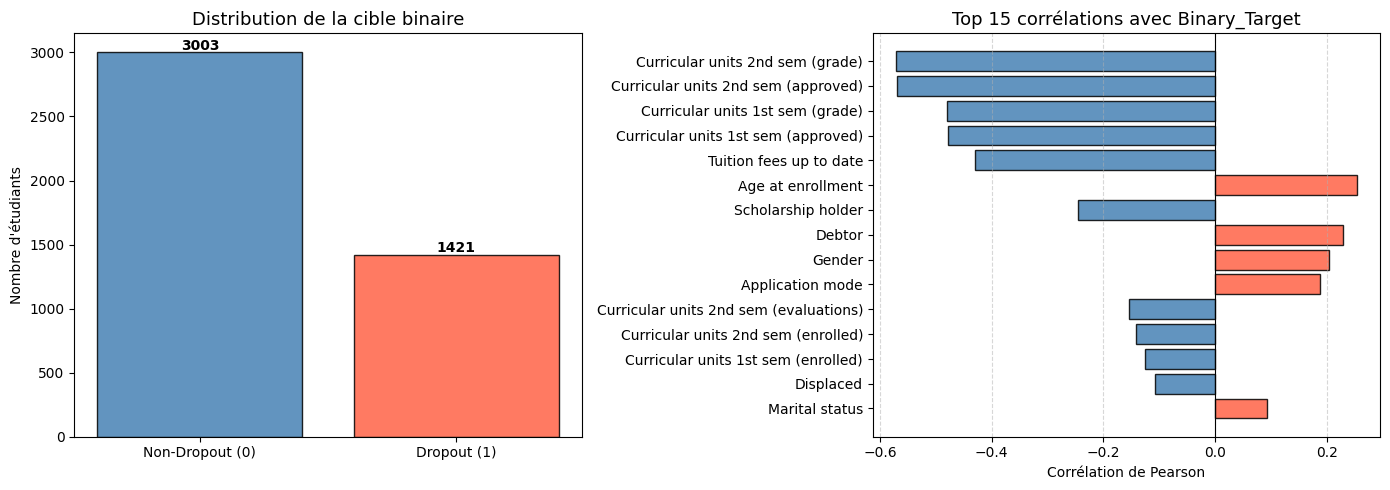

✅ EDA terminé.


In [ ]:

# Analyse du déséquilibre des classes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = ['Non-Dropout (0)', 'Dropout (1)']
counts = df_dataset['Binary_Target'].value_counts().sort_index()
axes[0].bar(labels, counts.values, color=['steelblue', 'tomato'], edgecolor='black', alpha=0.85)
axes[0].set_title('Distribution de la cible binaire', fontsize=13)
axes[0].set_ylabel('Nombre d\'étudiants')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# — Corrélation top 15 features numériques avec la cible
numeric_cols = df_dataset.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['Binary_Target']]
corr_with_target = df_dataset[numeric_cols + ['Binary_Target']].corr()['Binary_Target'].drop('Binary_Target')
top_corr = corr_with_target.abs().nlargest(15).index
corr_vals = corr_with_target[top_corr]
colors = ['tomato' if v > 0 else 'steelblue' for v in corr_vals.values]
axes[1].barh(top_corr[::-1], corr_vals[top_corr[::-1]].values, color=colors[::-1], edgecolor='black', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Top 15 corrélations avec Binary_Target', fontsize=13)
axes[1].set_xlabel('Corrélation de Pearson')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
print('✅ Analyse terminé.')

## Suppression Target + One-Hot Encoding (OHE)

In [ ]:

categorical_numeric_cols = [
    'Marital status', 'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation",
    'Displaced', 'Educational special needs', 'Debtor',
    'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (without evaluations)'
]

for col in categorical_numeric_cols:
    if col in df_dataset.columns:
        df_dataset[col] = df_dataset[col].astype('object')

# Suppression de la colonne Target originale
if 'Target' in df_dataset.columns:
    df_dataset = df_dataset.drop('Target', axis=1)

# OHE
object_cols = df_dataset.select_dtypes(include='object').columns.tolist()
df_dataset  = pd.get_dummies(df_dataset, columns=object_cols, drop_first=True)

print('✅ One-Hot Encoding effectué.')
print(f'   Dimensions finales : {df_dataset.shape}')

✅ One-Hot Encoding effectué.
   Dimensions finales : (4424, 277)


## Séparation des features et de la cible

In [ ]:

# Séparation X / y
X_inst = df_dataset.drop('Binary_Target', axis=1).astype(float)
y_inst = df_dataset['Binary_Target']

print(f'X : {X_inst.shape} | y : {y_inst.shape}')
print(f'Features : {X_inst.shape[1]} colonnes')

X : (4424, 276) | y : (4424,)
Features : 276 colonnes


## Split stratifié 70 / 15 / 15

In [ ]:

X_train_inst, X_temp, y_train_inst, y_temp = train_test_split(
    X_inst, y_inst,
    test_size=0.30,
    random_state=42,
    stratify=y_inst
)
X_val_inst, X_test_inst, y_val_inst, y_test_inst = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print('✅ Split stratifié effectué.')
print(f'   Train : {X_train_inst.shape[0]} lignes (70%)')
print(f'   Val   : {X_val_inst.shape[0]} lignes (15%)')
print(f'   Test  : {X_test_inst.shape[0]} lignes (15%)')
print(f'\n   Distribution train : {y_train_inst.value_counts().to_dict()}')
print(f'   Distribution val   : {y_val_inst.value_counts().to_dict()}')
print(f'   Distribution test  : {y_test_inst.value_counts().to_dict()}')

# Vérification du ratio dans chaque partition
for name, y in [('train', y_train_inst), ('val', y_val_inst), ('test', y_test_inst)]:
    ratio = y.mean()
    print(f'   % Dropout dans {name:<5} : {ratio:.2%}')

✅ Split stratifié effectué.
   Train : 3096 lignes (70%)
   Val   : 664 lignes (15%)
   Test  : 664 lignes (15%)

   Distribution train : {0: 2102, 1: 994}
   Distribution val   : {0: 450, 1: 214}
   Distribution test  : {0: 451, 1: 213}
   % Dropout dans train : 32.11%
   % Dropout dans val   : 32.23%
   % Dropout dans test  : 32.08%


## SMOTE sur l'ensemble d'entrainement X_train

In [ ]:

# SMOTE appliqué sur X_train
smote = SMOTE(random_state=42)
X_train_res_inst, y_train_res_inst = smote.fit_resample(X_train_inst, y_train_inst)

print('✅ SMOTE appliqué sur X_train (sans scaling préalable).')
print('Distribution après SMOTE :')
print(pd.Series(y_train_res_inst).value_counts())
print(f'X_train_res_inst : {X_train_res_inst.shape}')

✅ SMOTE appliqué sur X_train (sans scaling préalable).
Distribution après SMOTE :
Binary_Target
0    2102
1    2102
Name: count, dtype: int64
X_train_res_inst : (4204, 276)


## Sauvegarde des feature names

In [ ]:
# ══════════════════════════════════════════════════════
# Sauvegarde des feature names institutionnels
# Utilisé dans la Partie 3 pour l'alignement de l'input
# ══════════════════════════════════════════════════════
feature_names_inst = X_train_res_inst.columns.tolist()
joblib.dump(feature_names_inst, path_tools + 'feature_names_institutional.pkl')
print(f'✅ {len(feature_names_inst)} features sauvegardées → feature_names_institutional.pkl')

✅ 276 features sauvegardées → feature_names_institutional.pkl


## RF Baseline avec OOB Score

In [ ]:

# RF Baseline + OOB Score
rf_baseline = RandomForestClassifier(
    n_estimators=200,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rf_baseline.fit(X_train_res_inst, y_train_res_inst)

y_pred_base  = rf_baseline.predict(X_val_inst)
y_proba_base = rf_baseline.predict_proba(X_val_inst)[:, 1]

print('=== RF Baseline — Évaluation sur Val ===')
print(f'  OOB Score (train interne) : {rf_baseline.oob_score_:.4f}')
print(f'  Accuracy                  : {accuracy_score(y_val_inst, y_pred_base):.2%}')
print(f'  F1                        : {f1_score(y_val_inst, y_pred_base):.4f}')
print(f'  Rappel                    : {recall_score(y_val_inst, y_pred_base):.4f}')
print(f'  AUC-ROC                   : {roc_auc_score(y_val_inst, y_proba_base):.4f}')
print('\n→ Ces scores sont la référence avant tuning.')

=== RF Baseline — Évaluation sur Val ===
  OOB Score (train interne) : 0.9120
  Accuracy                  : 87.65%
  F1                        : 0.7940
  Rappel                    : 0.7383
  AUC-ROC                   : 0.9303

→ Ces scores sont la référence avant tuning.


## RandomizedSearchCV

In [ ]:

# Optimisation des hyperparamètres RF
param_distributions_rf = {
    'n_estimators'     : randint(100, 600),
    'max_depth'        : [None, 10, 20, 30, 40],
    'min_samples_split': randint(2, 12),
    'min_samples_leaf' : randint(1, 6),
    'max_features'     : ['sqrt', 'log2', 0.3, 0.5]
}

rf_tuning = RandomForestClassifier(
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

stratified_kfold_inst = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search_inst = RandomizedSearchCV(
    estimator=rf_tuning,
    param_distributions=param_distributions_rf,
    n_iter=80,
    scoring='f1',
    cv=stratified_kfold_inst,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
random_search_inst.fit(X_train_res_inst, y_train_res_inst)

print(f'\n✅ Meilleurs hyperparamètres : {random_search_inst.best_params_}')
print(f'✅ Meilleur score F1 (CV)     : {random_search_inst.best_score_:.4f}')

Fitting 5 folds for each of 80 candidates, totalling 400 fits

✅ Meilleurs hyperparamètres : {'max_depth': None, 'max_features': 0.3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 476}
✅ Meilleur score F1 (CV)     : 0.9085


## Sauvegarde du meilleur modèle RF institutionnel

In [ ]:

# Sauvegarde du meilleur modèle RF institutionnel

best_rf_inst = random_search_inst.best_estimator_

joblib.dump(best_rf_inst, path_tools + 'Dropout_model_institutional.pkl')
print(f'✅ Meilleur modèle RF institutionnel sauvegardé → Dropout_model_institutional.pkl')
print(f'   OOB Score du meilleur modèle : {best_rf_inst.oob_score_:.4f}')

✅ Meilleur modèle RF institutionnel sauvegardé → Dropout_model_institutional.pkl
   OOB Score du meilleur modèle : 0.9134


## Évaluation complète sur le jeu de test

=== Évaluation RF Institutionnel — Jeu de Test ===
  OOB Score (interne train)  : 0.9134
  Accuracy                   : 87.95%
  F1                         : 0.8068
  Précision                  : 0.8308
  Rappel                     : 0.7840
  AUC-ROC                    : 0.9339

Rapport détaillé :
              precision    recall  f1-score   support

 Non-Dropout       0.90      0.92      0.91       451
     Dropout       0.83      0.78      0.81       213

    accuracy                           0.88       664
   macro avg       0.87      0.85      0.86       664
weighted avg       0.88      0.88      0.88       664



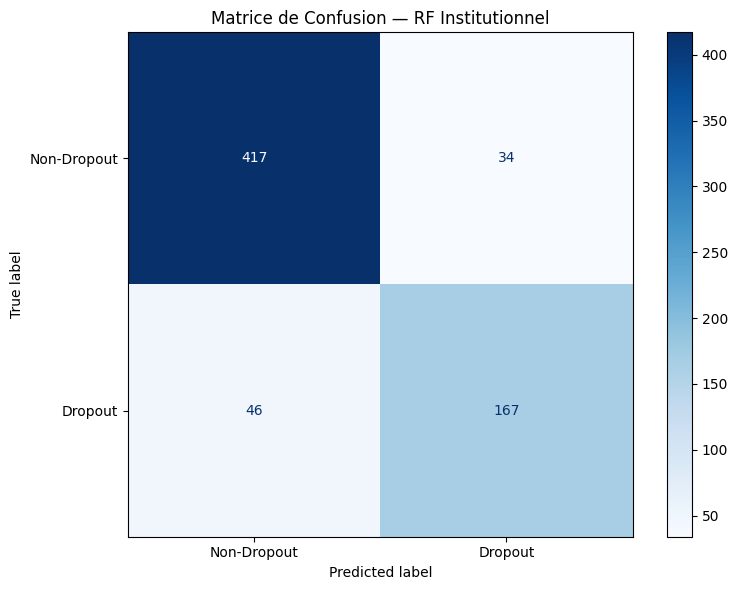

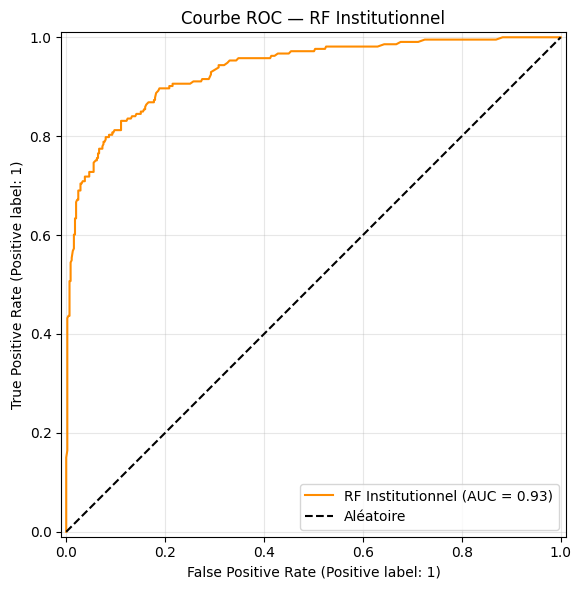

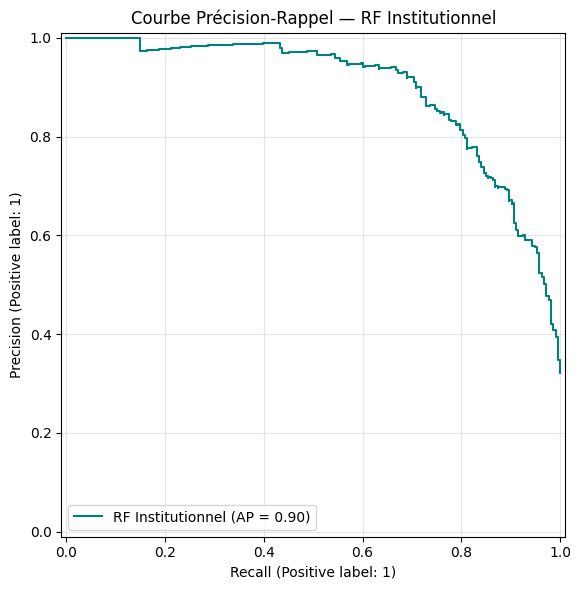

In [ ]:

# Évaluation complète RF institutionnel
y_pred_inst       = best_rf_inst.predict(X_test_inst)
y_pred_proba_inst = best_rf_inst.predict_proba(X_test_inst)[:, 1]

print('=== Évaluation RF Institutionnel — Jeu de Test ===')
print(f'  OOB Score (interne train)  : {best_rf_inst.oob_score_:.4f}')
print(f'  Accuracy                   : {accuracy_score(y_test_inst, y_pred_inst):.2%}')
print(f'  F1                         : {f1_score(y_test_inst, y_pred_inst):.4f}')
print(f'  Précision                  : {precision_score(y_test_inst, y_pred_inst):.4f}')
print(f'  Rappel                     : {recall_score(y_test_inst, y_pred_inst):.4f}')
print(f'  AUC-ROC                    : {roc_auc_score(y_test_inst, y_pred_proba_inst):.4f}')
print('\nRapport détaillé :')
print(classification_report(y_test_inst, y_pred_inst, target_names=['Non-Dropout', 'Dropout']))

# — Matrice de confusion
fig1, ax1 = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(
    confusion_matrix(y_test_inst, y_pred_inst),
    display_labels=['Non-Dropout', 'Dropout']
).plot(cmap=plt.cm.Blues, ax=ax1)
ax1.set_title('Matrice de Confusion — RF Institutionnel')
plt.tight_layout(); plt.show()

# — Courbe ROC
fig2, ax2 = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    y_test_inst, y_pred_proba_inst,
    name='RF Institutionnel', ax=ax2, color='darkorange'
)
ax2.plot([0, 1], [0, 1], 'k--', label='Aléatoire')
ax2.set_title('Courbe ROC — RF Institutionnel')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# — Courbe Précision-Rappel
fig3, ax3 = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(
    y_test_inst, y_pred_proba_inst,
    name='RF Institutionnel', ax=ax3, color='teal'
)
ax3.set_title('Courbe Précision-Rappel — RF Institutionnel')
ax3.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Importance des variables (Top 15)

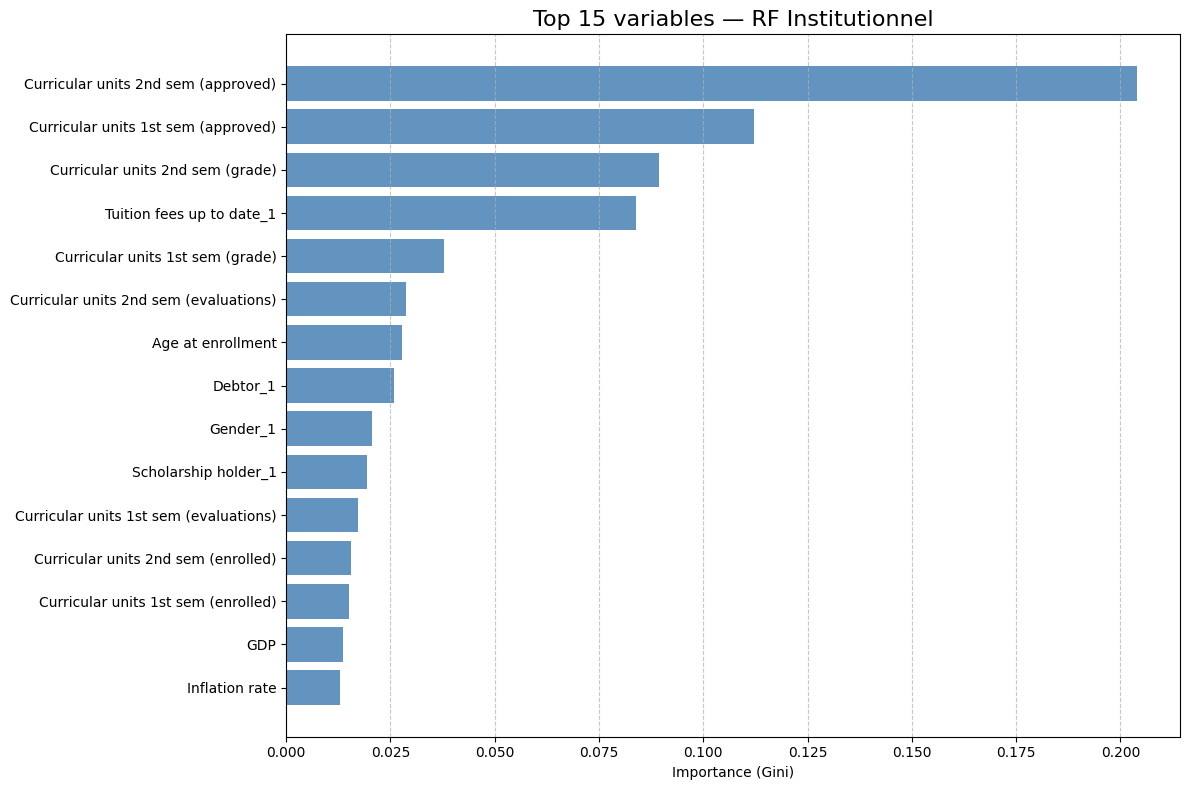

Top 15 features :
Curricular units 2nd sem (approved)       0.204077
Curricular units 1st sem (approved)       0.112060
Curricular units 2nd sem (grade)          0.089401
Tuition fees up to date_1                 0.083823
Curricular units 1st sem (grade)          0.037763
Curricular units 2nd sem (evaluations)    0.028749
Age at enrollment                         0.027802
Debtor_1                                  0.025932
Gender_1                                  0.020576
Scholarship holder_1                      0.019343
Curricular units 1st sem (evaluations)    0.017197
Curricular units 2nd sem (enrolled)       0.015520
Curricular units 1st sem (enrolled)       0.015055
GDP                                       0.013618
Inflation rate                            0.012989


In [ ]:

# Importance des variables RF institutionnel

importances_inst = best_rf_inst.feature_importances_
feat_series_inst = pd.Series(importances_inst, index=X_train_res_inst.columns)
top15_inst       = feat_series_inst.nlargest(15)

plt.figure(figsize=(12, 8))
plt.title('Top 15 variables — RF Institutionnel', fontsize=16)
plt.barh(top15_inst.index[::-1], top15_inst.values[::-1], color='steelblue', alpha=0.85)
plt.xlabel('Importance (Gini)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout(); plt.show()

print('Top 15 features :')
print(top15_inst.to_string())

# Seuil de décision optimal (Courbe PR)

✅ Seuil optimal RF institutionnel (sur Val) : 0.4307

=== Évaluation avec seuil optimal (sur Test) ===
  Accuracy  : 86.75%
  F1        : 0.7991
  Précision : 0.7778
  Rappel    : 0.8216
              precision    recall  f1-score   support

 Non-Dropout       0.91      0.89      0.90       451
     Dropout       0.78      0.82      0.80       213

    accuracy                           0.87       664
   macro avg       0.85      0.86      0.85       664
weighted avg       0.87      0.87      0.87       664



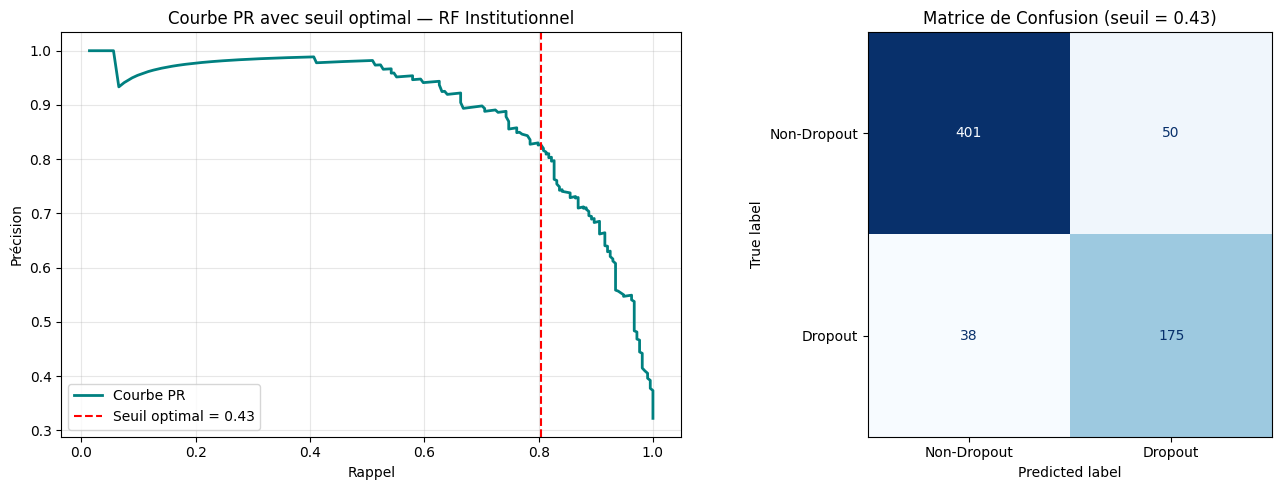


✅ Seuil optimal sauvegardé → seuil_optimal_rf_institutional.pkl


In [ ]:

# Seuil optimal sur le jeu de validation (évite la contamination du Test)
# On cherche le seuil maximisant le F1 sur Val
y_proba_val_inst  = best_rf_inst.predict_proba(X_val_inst)[:, 1]
prec_v, rec_v, thresh_v = precision_recall_curve(y_val_inst, y_proba_val_inst)
f1_v               = 2 * (prec_v * rec_v) / (prec_v + rec_v + 1e-8)
seuil_optimal_inst = thresh_v[np.argmax(f1_v[:-1])]

print(f'✅ Seuil optimal RF institutionnel (sur Val) : {seuil_optimal_inst:.4f}')

# Application sur Test
y_pred_inst_adj = (y_pred_proba_inst >= seuil_optimal_inst).astype(int)

print('\n=== Évaluation avec seuil optimal (sur Test) ===')
print(f'  Accuracy  : {accuracy_score(y_test_inst, y_pred_inst_adj):.2%}')
print(f'  F1        : {f1_score(y_test_inst, y_pred_inst_adj):.4f}')
print(f'  Précision : {precision_score(y_test_inst, y_pred_inst_adj):.4f}')
print(f'  Rappel    : {recall_score(y_test_inst, y_pred_inst_adj):.4f}')
print(classification_report(y_test_inst, y_pred_inst_adj, target_names=['Non-Dropout', 'Dropout']))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rec_v[:-1], prec_v[:-1], color='teal', linewidth=2, label='Courbe PR')
axes[0].axvline(
    rec_v[np.argmax(f1_v[:-1])], color='red', linestyle='--',
    label=f'Seuil optimal = {seuil_optimal_inst:.2f}'
)
axes[0].set_xlabel('Rappel'); axes[0].set_ylabel('Précision')
axes[0].set_title('Courbe PR avec seuil optimal — RF Institutionnel')
axes[0].legend(); axes[0].grid(alpha=0.3)

ConfusionMatrixDisplay(
    confusion_matrix(y_test_inst, y_pred_inst_adj),
    display_labels=['Non-Dropout', 'Dropout']
).plot(cmap=plt.cm.Blues, ax=axes[1], colorbar=False)
axes[1].set_title(f'Matrice de Confusion (seuil = {seuil_optimal_inst:.2f})')

plt.tight_layout(); plt.show()

# Sauvegarde du seuil optimal
joblib.dump(seuil_optimal_inst, path_tools + 'seuil_optimal_rf_institutional.pkl')
print(f'\n✅ Seuil optimal sauvegardé → seuil_optimal_rf_institutional.pkl')